## 1. Environment

In [1]:
# Install dependencies
%pip install -q numpy pandas matplotlib seaborn scikit-learn imbalanced-learn xgboost lightgbm catboost interpret shap statsmodels joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, glob

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, matthews_corrcoef, classification_report,
                             precision_recall_curve, balanced_accuracy_score)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN

from sklearn.linear_model import RidgeClassifier, PassiveAggressiveClassifier, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from interpret.glassbox import ExplainableBoostingClassifier

import shap
import joblib
from scipy.stats import spearmanr, kendalltau
from statsmodels.stats.contingency_tables import mcnemar as mc_test

import warnings
warnings.filterwarnings('ignore')
print("All modules loaded successfully!")


Note: you may need to restart the kernel to use updated packages.
All modules loaded successfully!


## 2. Load UNSW-NB15

In [2]:
DATA_DIR = './'   # <-- adjust to where the UNSW CSVs live

cands = sorted(set(glob.glob(os.path.join(DATA_DIR, '*NB15*.csv')) +
                   glob.glob(os.path.join(DATA_DIR, '*nb15*.csv'))))
assert cands, ('No UNSW-NB15 CSV found in DATA_DIR. Download '
               'UNSW_NB15_training-set.csv and UNSW_NB15_testing-set.csv '
               'from the UNSW Canberra research portal and place them here.')
print('Found files:', cands)

frames = [pd.read_csv(p, low_memory=False) for p in cands]
data = pd.concat(frames, ignore_index=True)
data.columns = [c.strip().lower() for c in data.columns]
assert 'attack_cat' in data.columns, f'attack_cat missing; got: {list(data.columns)[:12]}...'

# Normalise known label inconsistencies across UNSW distributions:
#   trailing spaces in the raw 4-part files; 'Backdoors' vs 'Backdoor';
#   NaN attack_cat for normal traffic in some versions.
data['attack_cat'] = (data['attack_cat'].astype(str).str.strip()
                      .replace({'Backdoors': 'Backdoor', 'nan': 'Normal', '': 'Normal'}))

# Drop identifier and the binary label (we do multiclass on attack_cat)
for col in ('id', 'label'):
    if col in data.columns:
        data.drop(columns=col, inplace=True)

print('Combined shape:', data.shape)
print('\nClass distribution:')
print(data['attack_cat'].value_counts())


Found files: ['./UNSW-NB15.csv', './UNSW_NB15_testing-set.csv', './UNSW_NB15_training-set.csv']
Combined shape: (433014, 43)

Class distribution:
attack_cat
Normal            149000
Generic            98871
Exploits           77918
Fuzzers            42430
DoS                28617
Reconnaissance     24478
Analysis            4677
Backdoor            4075
Shellcode           2644
Worms                304
Name: count, dtype: int64


## 3. Preprocessing

In [3]:
print('Preprocessing data...')
y_raw = data['attack_cat']
X_raw = data.drop(columns=['attack_cat'])

# Encode categorical features (different extractor family from CICFlowMeter —
# this is exactly why UNSW strengthens the generalisation claim)
cat_cols = [c for c in ('proto', 'service', 'state') if c in X_raw.columns]
for c in cat_cols:
    X_raw[c] = LabelEncoder().fit_transform(X_raw[c].astype(str))
print('Categorical columns encoded:', cat_cols)

# Numeric coercion + inf/NaN cleanup (same hygiene as CICIDS pipeline)
X_raw = X_raw.apply(pd.to_numeric, errors='coerce')
X_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
mask = ~X_raw.isna().any(axis=1)
X_raw, y_raw = X_raw[mask], y_raw[mask]

label_encoder = LabelEncoder()
y = pd.Series(label_encoder.fit_transform(y_raw), name='label')
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=X_raw.columns)
print('X:', X_scaled.shape, '| classes:', len(label_encoder.classes_))
print('Classes:', list(label_encoder.classes_))


Preprocessing data...
Categorical columns encoded: ['proto', 'service', 'state']
X: (433014, 42) | classes: 10
Classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


## 4a. Hybrid Feature Ranking (MI → RF, computed once and cached)

In [4]:
print('Running Hybrid Feature Selection...')
mi_selector = SelectKBest(score_func=mutual_info_classif, k=min(30, X_scaled.shape[1]))
mi_selector.fit(X_scaled, y)
mi_features = X_scaled.columns[mi_selector.get_support()]

rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_scaled[mi_features], y)
importances = rf.feature_importances_

ranked_features = list(mi_features[np.argsort(importances)[::-1]])
print('Hybrid ranking (best -> worst):')
for i, f in enumerate(ranked_features, 1):
    print(f'  {i:2d}. {f}')


Running Hybrid Feature Selection...
Hybrid ranking (best -> worst):
   1. sbytes
   2. sttl
   3. ct_dst_sport_ltm
   4. smean
   5. ct_srv_dst
   6. ct_dst_src_ltm
   7. ct_state_ttl
   8. ct_srv_src
   9. service
  10. dmean
  11. dload
  12. rate
  13. dbytes
  14. ct_src_dport_ltm
  15. sload
  16. dur
  17. dttl
  18. tcprtt
  19. proto
  20. sinpkt
  21. ct_dst_ltm
  22. synack
  23. ackdat
  24. dinpkt
  25. sjit
  26. dpkts
  27. spkts
  28. djit
  29. stcpb
  30. dtcpb


## 4b. Evaluation Set Preparation (+ capped SMOTE helper)

In [5]:
from collections import Counter

SMOTE_CAP = 50_000

def capped_sampling(y_arr):
    counts  = Counter(list(y_arr))
    ceiling = min(SMOTE_CAP, max(counts.values()))
    return {cls: (n if n >= ceiling else ceiling) for cls, n in counts.items()}

def make_smote():
    """Auto-tune k_neighbors to the rarest class's worst-case training fold."""
    min_n      = min(Counter(list(y_subset)).values())
    safe_train = max(1, int(min_n * 2 / 3))
    k          = max(1, min(5, safe_train - 1))
    return SMOTE(sampling_strategy=capped_sampling, k_neighbors=k, random_state=42)

X_scaled_r = X_scaled.reset_index(drop=True)
y_r        = y.reset_index(drop=True)

# UNSW is small enough for the full data — no subsample by default.
SUBSAMPLE_FRACTION = 1.0
if SUBSAMPLE_FRACTION < 1.0:
    print(f'Taking a {int(SUBSAMPLE_FRACTION*100)}% stratified sample...')
    all_idx = np.arange(len(y_r))
    _, sub_idx = train_test_split(all_idx, test_size=SUBSAMPLE_FRACTION,
                                  stratify=y_r, random_state=42)
else:
    print('Using the FULL dataset (no subsampling).')
    sub_idx = np.arange(len(y_r))

MIN_CLASS_SAMPLES = 15
y_sub_raw    = y_r.iloc[sub_idx].reset_index(drop=True)
class_counts = y_sub_raw.value_counts()
valid_classes = class_counts[class_counts >= MIN_CLASS_SAMPLES].index
keep_mask    = y_sub_raw.isin(valid_classes)
final_idx    = sub_idx[keep_mask.values]
print(f'Removed {len(class_counts) - len(valid_classes)} class(es) with '
      f'< {MIN_CLASS_SAMPLES} samples.')

X_full_subset = X_scaled_r.iloc[final_idx].reset_index(drop=True)
y_subset_raw  = y_r.iloc[final_idx].reset_index(drop=True)

# Consecutive re-encoding (required by XGBoost-style label contracts and used
# uniformly across the pipeline)
subset_le = LabelEncoder()
y_subset  = pd.Series(subset_le.fit_transform(y_subset_raw), name='label', dtype=int)
class_names_subset = [label_encoder.classes_[orig] for orig in subset_le.classes_]
n_classes = int(y_subset.nunique())

print(f'\nEvaluation set: {X_full_subset.shape} | {n_classes} classes | '
      f'min class size = {y_subset.value_counts().min()}')
print('\nClass label map:')
for i, name in enumerate(class_names_subset):
    print(f'  {i:2d}  {name:16s} (n = {int((y_subset == i).sum()):,})')


Using the FULL dataset (no subsampling).
Removed 0 class(es) with < 15 samples.

Evaluation set: (433014, 42) | 10 classes | min class size = 304

Class label map:
   0  Analysis         (n = 4,677)
   1  Backdoor         (n = 4,075)
   2  DoS              (n = 28,617)
   3  Exploits         (n = 77,918)
   4  Fuzzers          (n = 42,430)
   5  Generic          (n = 98,871)
   6  Normal           (n = 149,000)
   7  Reconnaissance   (n = 24,478)
   8  Shellcode        (n = 2,644)
   9  Worms            (n = 304)


## 4c. Feature-Count Ablation (auto-adopts the argmax K)

K=10 features -> validation accuracy 0.8188
K=15 features -> validation accuracy 0.8357
K=20 features -> validation accuracy 0.8430
K=25 features -> validation accuracy 0.8445
K=30 features -> validation accuracy 0.8444

Auto-adopted SELECTED_K = 25 (argmax of the sweep).


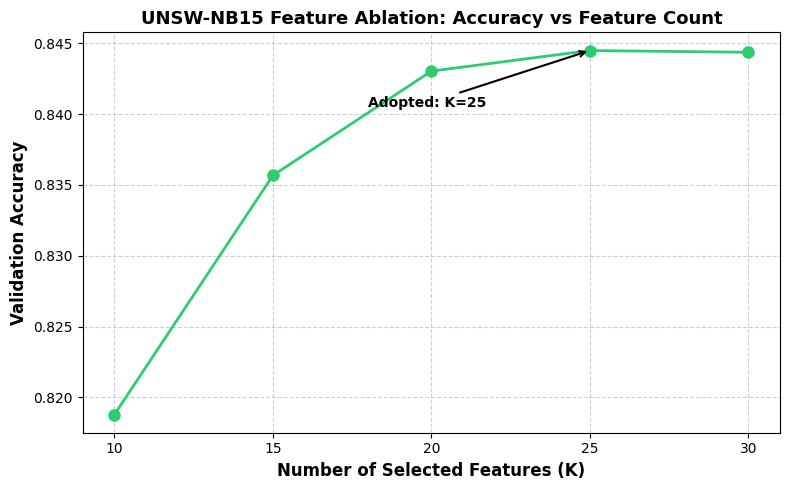

Saved -> FigU1_Feature_Ablation_UNSW.png


In [6]:
K_values = [10, 15, 20, 25, 30]
K_values = [k for k in K_values if k <= len(ranked_features)]
feat_sweep_acc = []
skf_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for K in K_values:
    feats_K = ranked_features[:K]
    Xk = X_full_subset[feats_K]
    ens_K = VotingClassifier(estimators=[
        ('CatBoost', CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1,
                                        loss_function='MultiClass', random_seed=42,
                                        verbose=0, thread_count=-1)),
        ('ExtraTrees', ExtraTreesClassifier(n_estimators=150, n_jobs=-1,
                                            random_state=42)),
    ], voting='soft')
    pipe_K = Pipeline([('smote', make_smote()), ('classifier', ens_K)])
    scores = cross_val_score(pipe_K, Xk, y_subset, cv=skf_fast, scoring='accuracy', n_jobs=1)
    feat_sweep_acc.append(np.mean(scores))
    print(f'K={K:2d} features -> validation accuracy {np.mean(scores):.4f}')

SELECTED_K = K_values[int(np.argmax(feat_sweep_acc))]
selected_features = ranked_features[:SELECTED_K]
X_subset = X_full_subset[selected_features]
print(f'\nAuto-adopted SELECTED_K = {SELECTED_K} (argmax of the sweep).')

plt.figure(figsize=(8, 5))
plt.plot(K_values, feat_sweep_acc, marker='o', linewidth=2, color='#2ecc71', markersize=8)
plt.annotate(f'Adopted: K={SELECTED_K}',
             xy=(SELECTED_K, max(feat_sweep_acc)),
             xytext=(SELECTED_K - 7, max(feat_sweep_acc) - 0.004),
             fontsize=10, fontweight='bold',
             arrowprops=dict(arrowstyle='->', lw=1.5))
plt.title('UNSW-NB15 Feature Ablation: Accuracy vs Feature Count',
          fontsize=13, fontweight='bold')
plt.xlabel('Number of Selected Features (K)', fontsize=12, fontweight='bold')
plt.ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(K_values)
plt.tight_layout()
plt.savefig('FigU1_Feature_Ablation_UNSW.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved -> FigU1_Feature_Ablation_UNSW.png')


## 5. Model Zoo (identical configuration to the CICIDS run — disclosed)

In [7]:
EBM_TRAIN_CAP = 100_000   # same cap as CICIDS run; UNSW folds are smaller anyway
CAL_FRACTION  = 0.10

def fresh_base_models():
    return {
        'CatBoost': CatBoostClassifier(
            iterations=200, depth=6, learning_rate=0.1,
            loss_function='MultiClass', random_seed=42,
            verbose=0, thread_count=-1),
        'ExtraTrees': ExtraTreesClassifier(
            n_estimators=200, n_jobs=-1, random_state=42),
        'EBM': ExplainableBoostingClassifier(
            max_bins=64, interactions=0, outer_bags=2, max_rounds=2000,
            n_jobs=-1, random_state=42),
    }

def fresh_reference_models():
    return {'LightGBM (reference)': LGBMClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=6,
        random_state=42, n_jobs=-1, verbose=-1)}

def fresh_baseline():
    ridge = CalibratedClassifierCV(RidgeClassifier(class_weight='balanced'), cv=3)
    nbay  = GaussianNB()
    pac   = CalibratedClassifierCV(
        PassiveAggressiveClassifier(max_iter=1000, random_state=42), cv=3)
    return VotingClassifier(estimators=[
        ('Ridge', ridge), ('Naive Bayes', nbay), ('Passive Aggressive', pac)
    ], voting='soft', weights=[1, 1, 4])

def fresh_meta():
    return LogisticRegression(max_iter=1000, random_state=42)

VOTE_KEY   = 'Voting (CB+ET+EBM)'
STACK_KEY  = 'Stacking (CB+ET+EBM)'
THRESH_KEY = 'Stacking + Thresholds'
BASE_KEY   = 'Baseline Ensemble'
print('Model zoo defined.')


Model zoo defined.


## 6a. Unified 5-Fold Harness (leak-proof, fully paired)

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ALL_KEYS = ['CatBoost', 'ExtraTrees', 'EBM', 'LightGBM (reference)',
            BASE_KEY, VOTE_KEY, STACK_KEY, THRESH_KEY]
fold_metrics = {k: {'acc': [], 'f1': [], 'f1_macro': [], 'mcc': [],
                    'inf_us': [], 'inf_par_us': []} for k in ALL_KEYS}
pooled_preds = {k: [] for k in ALL_KEYS}
pooled_true  = []
fold_thresholds = []
fitted_bases = None
fitted_meta  = None

def record(key, y_te, y_hat, inf_us, inf_par_us=None):
    fold_metrics[key]['acc'].append(accuracy_score(y_te, y_hat))
    fold_metrics[key]['f1'].append(f1_score(y_te, y_hat, average='weighted'))
    fold_metrics[key]['f1_macro'].append(f1_score(y_te, y_hat, average='macro'))
    fold_metrics[key]['mcc'].append(matthews_corrcoef(y_te, y_hat))
    fold_metrics[key]['inf_us'].append(inf_us)
    fold_metrics[key]['inf_par_us'].append(inf_par_us if inf_par_us is not None else inf_us)
    pooled_preds[key].extend(y_hat)

t_start = time.time()
for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_subset, y_subset), 1):
    print(f"\n===== Fold {fold_i}/5 =====")
    X_tr, X_te = X_subset.iloc[train_idx], X_subset.iloc[test_idx]
    y_tr, y_te = y_subset.iloc[train_idx], y_subset.iloc[test_idx]
    pooled_true.extend(y_te)

    X_core, X_cal, y_core, y_cal = train_test_split(
        X_tr, y_tr, test_size=CAL_FRACTION, stratify=y_tr, random_state=42)

    sm = make_smote()
    X_res, y_res = sm.fit_resample(X_core, y_core)
    X_fit, X_blend, y_fit, y_blend = train_test_split(
        X_res, y_res, test_size=0.20, stratify=y_res, random_state=42)
    print(f"fit={len(X_fit):,} blend={len(X_blend):,} cal={len(X_cal):,} test={len(X_te):,}")

    bases = fresh_base_models()
    P_blend, P_test, P_cal = {}, {}, {}
    member_inf = {}

    for name, model in bases.items():
        if name == 'EBM' and EBM_TRAIN_CAP is not None and len(X_fit) > EBM_TRAIN_CAP:
            X_ebm, _, y_ebm, _ = train_test_split(
                X_fit, y_fit, train_size=EBM_TRAIN_CAP,
                stratify=y_fit, random_state=42)
            print(f"  EBM training capped at {EBM_TRAIN_CAP:,} rows")
        else:
            X_ebm, y_ebm = X_fit, y_fit

        t0 = time.time()
        model.fit(X_ebm if name == 'EBM' else X_fit,
                  y_ebm if name == 'EBM' else y_fit)
        fit_s = time.time() - t0

        P_blend[name] = model.predict_proba(X_blend)
        P_cal[name]   = model.predict_proba(X_cal)
        t0 = time.time()
        P_test[name]  = model.predict_proba(X_te)
        inf_us = (time.time() - t0) / len(X_te) * 1e6
        member_inf[name] = inf_us

        y_hat = np.argmax(P_test[name], axis=1)
        record(name, y_te, y_hat, inf_us)
        print(f"  {name:12s} fit {fit_s:7.1f}s | acc {fold_metrics[name]['acc'][-1]:.4f} "
              f"| wF1 {fold_metrics[name]['f1'][-1]:.4f} "
              f"| mF1 {fold_metrics[name]['f1_macro'][-1]:.4f}")

    seq_lat = sum(member_inf.values())
    par_lat = max(member_inf.values())

    Pv = np.mean([P_test[n] for n in bases], axis=0)
    record(VOTE_KEY, y_te, np.argmax(Pv, axis=1), seq_lat, par_lat)

    meta = fresh_meta()
    Zb = np.hstack([P_blend[n] for n in bases])
    Zt = np.hstack([P_test[n]  for n in bases])
    Zc = np.hstack([P_cal[n]   for n in bases])
    meta.fit(Zb, y_blend)
    t0 = time.time()
    Pt_meta = meta.predict_proba(Zt)
    meta_us = (time.time() - t0) / len(X_te) * 1e6
    record(STACK_KEY, y_te, np.argmax(Pt_meta, axis=1),
           seq_lat + meta_us, par_lat + meta_us)

    Pcal_meta = meta.predict_proba(Zc)
    y_cal_arr = np.asarray(y_cal)
    thr = np.full(n_classes, 0.5)
    for c in range(n_classes):
        y_bin = (y_cal_arr == c).astype(int)
        if y_bin.sum() < 3 or y_bin.sum() == len(y_bin):
            continue
        prec, rec, t = precision_recall_curve(y_bin, Pcal_meta[:, c])
        f1s = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
        f1s = f1s[:-1]
        if len(f1s) == 0 or not np.isfinite(f1s).any():
            continue
        thr[c] = float(np.clip(t[int(np.nanargmax(f1s))], 1e-6, 1 - 1e-6))
    fold_thresholds.append(thr.copy())
    record(THRESH_KEY, y_te, np.argmax(Pt_meta / thr[None, :], axis=1),
           seq_lat + meta_us, par_lat + meta_us)
    print(f"  {STACK_KEY}: mF1 {fold_metrics[STACK_KEY]['f1_macro'][-1]:.4f} -> "
          f"{THRESH_KEY}: mF1 {fold_metrics[THRESH_KEY]['f1_macro'][-1]:.4f}")

    for name, model in fresh_reference_models().items():
        model.fit(X_fit, y_fit)
        t0 = time.time(); y_hat = model.predict(X_te)
        record(name, y_te, y_hat, (time.time() - t0) / len(X_te) * 1e6)

    bl = fresh_baseline()
    bl.fit(X_fit, y_fit)
    t0 = time.time(); y_hat = bl.predict(X_te)
    record(BASE_KEY, y_te, y_hat, (time.time() - t0) / len(X_te) * 1e6)

    if fold_i == skf.get_n_splits():
        fitted_bases, fitted_meta = bases, meta

print(f"\nTotal harness time: {(time.time()-t_start)/60:.1f} min")
mean_thresholds = np.mean(np.stack(fold_thresholds), axis=0)
print("Mean tuned thresholds per class:")
for c in range(n_classes):
    print(f"  {class_names_subset[c]:18s} t = {mean_thresholds[c]:.4f}")

mcnemar_data = {k: list(v) for k, v in pooled_preds.items()}
mcnemar_data['true'] = list(pooled_true)
y_true_all = np.array(pooled_true)



===== Fold 1/5 =====
fit=467,653 blend=116,914 cal=34,642 test=86,603
  CatBoost     fit    49.2s | acc 0.7757 | wF1 0.7919 | mF1 0.5441
  ExtraTrees   fit    14.6s | acc 0.8401 | wF1 0.8531 | mF1 0.6632
  EBM training capped at 100,000 rows
  EBM          fit   285.3s | acc 0.7645 | wF1 0.7830 | mF1 0.5330
  Stacking (CB+ET+EBM): mF1 0.6724 -> Stacking + Thresholds: mF1 0.6881

===== Fold 2/5 =====
fit=467,653 blend=116,914 cal=34,642 test=86,603
  CatBoost     fit    48.9s | acc 0.7816 | wF1 0.7974 | mF1 0.5508
  ExtraTrees   fit    13.9s | acc 0.8455 | wF1 0.8560 | mF1 0.6643
  EBM training capped at 100,000 rows
  EBM          fit   286.3s | acc 0.7709 | wF1 0.7884 | mF1 0.5380
  Stacking (CB+ET+EBM): mF1 0.6682 -> Stacking + Thresholds: mF1 0.6918

===== Fold 3/5 =====
fit=467,654 blend=116,914 cal=34,642 test=86,603
  CatBoost     fit    49.8s | acc 0.7808 | wF1 0.7966 | mF1 0.5501
  ExtraTrees   fit    15.0s | acc 0.8424 | wF1 0.8544 | mF1 0.6663
  EBM training capped at 100,00

## 6b. Component Ablation Table (manuscript Section 4.7, Table U1)

In [9]:
rows = {}
for k in ALL_KEYS:
    rows[k] = {
        'Accuracy': np.mean(fold_metrics[k]['acc']),
        'F1_weighted': np.mean(fold_metrics[k]['f1']),
        'F1_macro': np.mean(fold_metrics[k]['f1_macro']),
        'MCC': np.mean(fold_metrics[k]['mcc']),
        'Lat_seq_us': np.mean(fold_metrics[k]['inf_us']),
        'Lat_par_us': np.mean(fold_metrics[k]['inf_par_us']),
    }
order = [BASE_KEY, 'LightGBM (reference)', 'CatBoost', 'ExtraTrees', 'EBM',
         VOTE_KEY, STACK_KEY, THRESH_KEY]
table1 = pd.DataFrame(rows).T.loc[order].round(4)
print('================ TABLE U1 (UNSW-NB15, copy into Section 4.7) ================')
print(table1.to_string())
table1.to_csv('TableU1_UNSW_component_ablation.csv')

base_names = ['CatBoost', 'ExtraTrees', 'EBM']
best_base = max(base_names, key=lambda n: rows[n]['F1_weighted'])
for comb in (VOTE_KEY, STACK_KEY):
    v = 'BEATS' if rows[comb]['F1_weighted'] >= rows[best_base]['F1_weighted'] else 'does NOT beat'
    print(f"{comb}: wF1={rows[comb]['F1_weighted']:.4f} {v} best base "
          f"({best_base}, wF1={rows[best_base]['F1_weighted']:.4f})")
ref = 'LightGBM (reference)'
for comb in (VOTE_KEY, STACK_KEY):
    v = 'BEATS' if rows[comb]['F1_weighted'] >= rows[ref]['F1_weighted'] else 'does NOT beat'
    print(f"{comb}: {v} the LightGBM reference (wF1={rows[ref]['F1_weighted']:.4f})")
v = 'IMPROVES' if rows[THRESH_KEY]['F1_macro'] >= rows[STACK_KEY]['F1_macro'] else 'does NOT improve'
print(f"{THRESH_KEY}: macro-F1 {rows[THRESH_KEY]['F1_macro']:.4f} {v} on raw stacking "
      f"({rows[STACK_KEY]['F1_macro']:.4f})")
print('\nWrite Section 4.7 to match these verdicts EXACTLY — replication or')
print('non-replication of the CICIDS pattern are both reportable findings.')


================ TABLE U1 (UNSW-NB15, copy into Section 4.7) ================
                       Accuracy  F1_weighted  F1_macro     MCC  Lat_seq_us  Lat_par_us
Baseline Ensemble        0.5476       0.5983    0.2779  0.4813      1.5578      1.5578
LightGBM (reference)     0.7999       0.8130    0.5990  0.7533      5.7614      5.7614
CatBoost                 0.7782       0.7945    0.5471  0.7287      0.2391      0.2391
ExtraTrees               0.8422       0.8544    0.6639  0.8036     15.0773     15.0773
EBM                      0.7661       0.7851    0.5331  0.7126      0.5987      0.5987
Voting (CB+ET+EBM)       0.8277       0.8406    0.6076  0.7881     15.9151     15.0773
Stacking (CB+ET+EBM)     0.8439       0.8554    0.6713  0.8043     16.0461     15.2082
Stacking + Thresholds    0.8567       0.8591    0.6931  0.8172     16.0461     15.2082
Voting (CB+ET+EBM): wF1=0.8406 does NOT beat best base (ExtraTrees, wF1=0.8544)
Stacking (CB+ET+EBM): wF1=0.8554 BEATS best base (ExtraTree

## 6c. Threshold Calibration Analysis (rarest four classes, auto-selected)

Auto-selected focus classes (rarest 4): ['Worms', 'Shellcode', 'Backdoor', 'Analysis']

===== THRESHOLD CALIBRATION (UNSW): before vs after =====
    Class  Stage  Precision  Recall    F1  FalseAlarms_per_100k
    Worms before      0.680   0.789 0.731                  26.1
    Worms  after      0.777   0.743 0.760                  15.0
Shellcode before      0.779   0.861 0.818                 149.0
Shellcode  after      0.831   0.825 0.828                 102.8
 Backdoor before      0.108   0.189 0.137                1472.7
 Backdoor  after      0.378   0.135 0.199                 208.5
 Analysis before      0.151   0.272 0.195                1648.0
 Analysis  after      0.652   0.212 0.320                 121.9

Macro-F1:          0.6714 -> 0.6934
Balanced accuracy: 0.6940 -> 0.6733


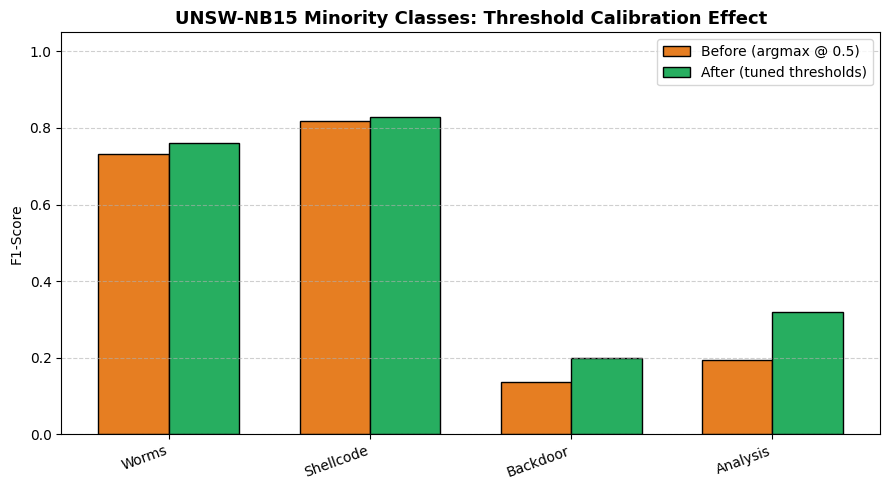

Saved -> Table_threshold_calibration_UNSW.csv, FigU8_Threshold_Calibration_UNSW.png


In [10]:
y_before = np.array(mcnemar_data[STACK_KEY])
y_after  = np.array(mcnemar_data[THRESH_KEY])
N = len(y_true_all)

support = y_subset.value_counts()
focus = [int(c) for c in support.sort_values().index[:4]]
print('Auto-selected focus classes (rarest 4):',
      [class_names_subset[c] for c in focus])

rows_thr = []
for c in focus:
    name = class_names_subset[c]
    for tag, yp in (('before', y_before), ('after', y_after)):
        tp = int(np.sum((yp == c) & (y_true_all == c)))
        fp = int(np.sum((yp == c) & (y_true_all != c)))
        fn = int(np.sum((yp != c) & (y_true_all == c)))
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec  = tp / (tp + fn) if tp + fn else 0.0
        f1c  = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        rows_thr.append({'Class': name, 'Stage': tag,
                         'Precision': round(prec, 3), 'Recall': round(rec, 3),
                         'F1': round(f1c, 3),
                         'FalseAlarms_per_100k': round(fp / N * 1e5, 1)})
thr_table = pd.DataFrame(rows_thr)
print('\n===== THRESHOLD CALIBRATION (UNSW): before vs after =====')
print(thr_table.to_string(index=False))
thr_table.to_csv('Table_threshold_calibration_UNSW.csv', index=False)

print(f"\nMacro-F1:          {f1_score(y_true_all, y_before, average='macro'):.4f} -> "
      f"{f1_score(y_true_all, y_after, average='macro'):.4f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_true_all, y_before):.4f} -> "
      f"{balanced_accuracy_score(y_true_all, y_after):.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
classes = [class_names_subset[c] for c in focus]
b_vals = [thr_table[(thr_table['Class'] == n) & (thr_table['Stage'] == 'before')]['F1'].iloc[0] for n in classes]
a_vals = [thr_table[(thr_table['Class'] == n) & (thr_table['Stage'] == 'after')]['F1'].iloc[0]  for n in classes]
x = np.arange(len(classes)); w = 0.35
ax.bar(x - w/2, b_vals, w, label='Before (argmax @ 0.5)', color='#e67e22', edgecolor='black')
ax.bar(x + w/2, a_vals, w, label='After (tuned thresholds)', color='#27ae60', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(classes, rotation=20, ha='right')
ax.set_ylabel('F1-Score'); ax.set_ylim(0, 1.05)
ax.set_title('UNSW-NB15 Minority Classes: Threshold Calibration Effect',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('FigU8_Threshold_Calibration_UNSW.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved -> Table_threshold_calibration_UNSW.csv, FigU8_Threshold_Calibration_UNSW.png')


## 6d. Resampler Comparison on the Rarest Classes (SMOTE vs ADASYN)

In [11]:
focus_names = [class_names_subset[c] for c in focus]
focus_ids   = list(focus)
print('Focus classes:', focus_names)

_min_n_rem  = y_subset.value_counts().min()
_safe_k_rem = max(1, min(5, int(_min_n_rem * 4 / 5) - 1))

def evaluate_sampler(sampler, sampler_name):
    print(f"\n=== Resampler: {sampler_name} ===")
    clf = VotingClassifier(estimators=[
        ('CatBoost', CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1,
                                        loss_function='MultiClass', random_seed=42,
                                        verbose=0, thread_count=-1)),
        ('ExtraTrees', ExtraTreesClassifier(n_estimators=200, n_jobs=-1,
                                            random_state=42)),
    ], voting='soft')
    pipe = Pipeline([("resample", sampler), ("classifier", clf)])
    yt_all, yp_all = [], []
    for train_idx, test_idx in skf.split(X_subset, y_subset):
        X_tr, X_te = X_subset.iloc[train_idx], X_subset.iloc[test_idx]
        y_tr, y_te = y_subset.iloc[train_idx], y_subset.iloc[test_idx]
        try:
            pipe.fit(X_tr, y_tr)
        except Exception as e:
            print(f"  {sampler_name} failed on a fold: {e}")
            return None
        yt_all.extend(y_te)
        yp_all.extend(pipe.predict(X_te))
    rep = classification_report(np.array(yt_all), np.array(yp_all),
                                output_dict=True, zero_division=0)
    out = {}
    for lid, nm in zip(focus_ids, focus_names):
        key = str(lid)
        if key in rep:
            out[nm] = {"precision": rep[key]["precision"],
                       "recall":    rep[key]["recall"],
                       "f1":        rep[key]["f1-score"]}
    return out

res_smote  = evaluate_sampler(
    SMOTE(sampling_strategy=capped_sampling, k_neighbors=_safe_k_rem, random_state=42),
    "SMOTE (baseline)")
res_adasyn = evaluate_sampler(
    ADASYN(sampling_strategy=capped_sampling, random_state=42),
    "ADASYN")

comp_rows = []
for nm in focus_names:
    s_r = (res_smote  or {}).get(nm, {})
    a_r = (res_adasyn or {}).get(nm, {})
    comp_rows.append({
        "Class": nm,
        "P (SMOTE)":   round(s_r.get("precision", float("nan")), 3),
        "R (SMOTE)":   round(s_r.get("recall",    float("nan")), 3),
        "F1 (SMOTE)":  round(s_r.get("f1",        float("nan")), 3),
        "P (ADASYN)":  round(a_r.get("precision", float("nan")), 3),
        "R (ADASYN)":  round(a_r.get("recall",    float("nan")), 3),
        "F1 (ADASYN)": round(a_r.get("f1",        float("nan")), 3),
    })
remediation_table = pd.DataFrame(comp_rows)
print("\n========= RESAMPLER COMPARISON (UNSW) =========")
print(remediation_table.to_string(index=False))
remediation_table.to_csv("Table_minority_remediation_UNSW.csv", index=False)
print('Saved -> Table_minority_remediation_UNSW.csv')


Focus classes: ['Worms', 'Shellcode', 'Backdoor', 'Analysis']

=== Resampler: SMOTE (baseline) ===

=== Resampler: ADASYN ===

========= RESAMPLER COMPARISON (UNSW) =========
    Class  P (SMOTE)  R (SMOTE)  F1 (SMOTE)  P (ADASYN)  R (ADASYN)  F1 (ADASYN)
    Worms      0.539      0.914       0.678       0.503       0.914        0.649
Shellcode      0.625      0.966       0.759       0.604       0.970        0.745
 Backdoor      0.115      0.206       0.148       0.115       0.186        0.142
 Analysis      0.224      0.244       0.234       0.149       0.273        0.193
Saved -> Table_minority_remediation_UNSW.csv


## 7. Paired McNemar Tests + Effect Sizes

In [12]:
def pairwise_mcnemar(key_a, key_b):
    a = np.array(mcnemar_data[key_a]); b = np.array(mcnemar_data[key_b])
    t = np.array(mcnemar_data['true'])
    both    = np.sum((a == t) & (b == t))
    a_only  = np.sum((a == t) & (b != t))
    b_only  = np.sum((a != t) & (b == t))
    neither = np.sum((a != t) & (b != t))
    res = mc_test([[both, a_only], [b_only, neither]], exact=False, correction=True)
    p = res.pvalue
    print(f"{key_a:28s} vs {key_b:24s} | A-only: {a_only:6d} | B-only: {b_only:6d} "
          f"| p = {p:.3e}{'  << significant' if p < 0.05 else '  (n.s.)'}")
    return p

print("Pairwise McNemar tests (UNSW-NB15):\n")
base_names = ['CatBoost', 'ExtraTrees', 'EBM']
best_base = max(base_names, key=lambda n: np.mean(fold_metrics[n]['f1']))
pairwise_mcnemar(BASE_KEY, STACK_KEY)
pairwise_mcnemar(best_base, STACK_KEY)
pairwise_mcnemar('LightGBM (reference)', STACK_KEY)
pairwise_mcnemar(VOTE_KEY, STACK_KEY)
pairwise_mcnemar(STACK_KEY, THRESH_KEY)

for a, b in [(best_base, STACK_KEY), ('LightGBM (reference)', STACK_KEY)]:
    ea = np.mean(np.array(mcnemar_data[a]) != np.array(mcnemar_data['true']))
    eb = np.mean(np.array(mcnemar_data[b]) != np.array(mcnemar_data['true']))
    rel = (ea - eb) / ea * 100 if ea > 0 else float('nan')
    print(f'Relative error reduction, {b} vs {a}: {rel:+.1f}% '
          f'(error {ea*100:.3f}% -> {eb*100:.3f}%)')


Pairwise McNemar tests (UNSW-NB15):

Baseline Ensemble            vs Stacking (CB+ET+EBM)     | A-only:   5096 | B-only: 133405 | p = 0.000e+00  << significant
ExtraTrees                   vs Stacking (CB+ET+EBM)     | A-only:   3887 | B-only:   4631 | p = 8.249e-16  << significant
LightGBM (reference)         vs Stacking (CB+ET+EBM)     | A-only:  10413 | B-only:  29484 | p = 0.000e+00  << significant
Voting (CB+ET+EBM)           vs Stacking (CB+ET+EBM)     | A-only:   7689 | B-only:  14699 | p = 0.000e+00  << significant
Stacking (CB+ET+EBM)         vs Stacking + Thresholds    | A-only:   8082 | B-only:  13600 | p = 3.131e-307  << significant
Relative error reduction, Stacking (CB+ET+EBM) vs ExtraTrees: +1.1% (error 15.780% -> 15.608%)
Relative error reduction, Stacking (CB+ET+EBM) vs LightGBM (reference): +22.0% (error 20.013% -> 15.608%)


## 8a. SHAP on the CatBoost Component

Generating SHAP explanations (CatBoost component)...


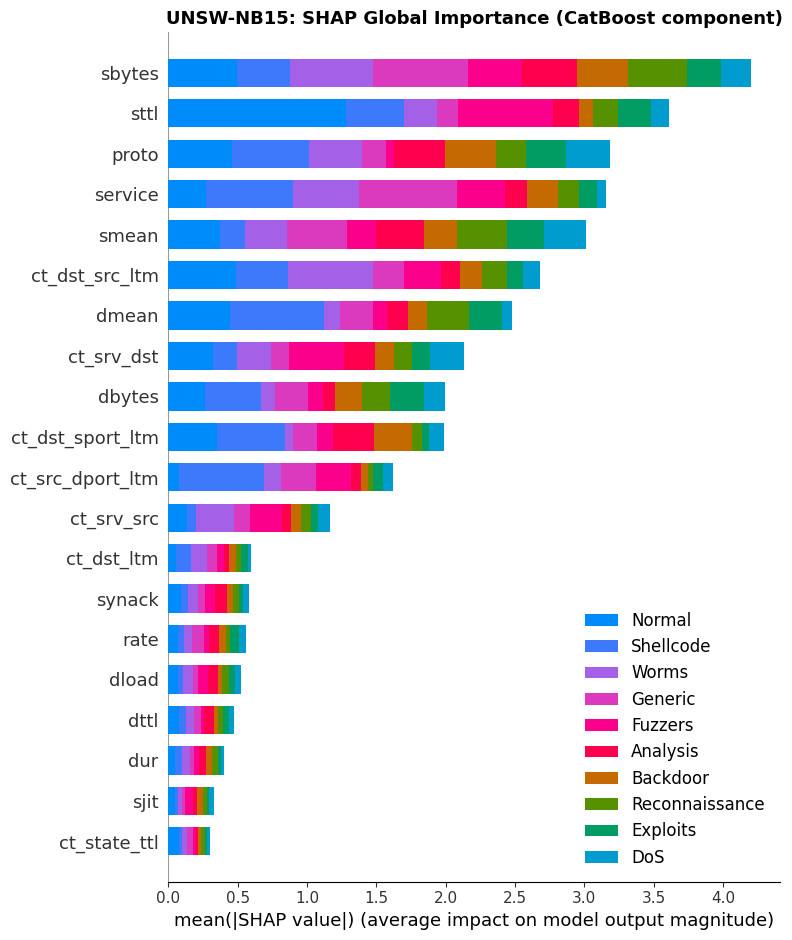

Saved -> FigU4a_SHAP_Bar_UNSW.png


In [13]:
print("Generating SHAP explanations (CatBoost component)...")
try:
    cat_model = fitted_bases['CatBoost']
    X_background = X_subset.sample(min(1000, len(X_subset)), random_state=42)
    explainer = shap.TreeExplainer(cat_model)
    shap_values = explainer.shap_values(X_background)
    if isinstance(shap_values, list):
        sv = np.stack(shap_values, axis=-1)
    else:
        sv = np.array(shap_values)
        if sv.ndim == 3 and sv.shape[0] == len(class_names_subset):
            sv = np.transpose(sv, (1, 2, 0))
    shap_global = np.abs(sv).mean(axis=(0, 2))
    shap_global_series = pd.Series(shap_global, index=X_background.columns)

    plt.figure(figsize=(10, 7))
    shap.summary_plot([sv[:, :, c] for c in range(sv.shape[2])], X_background,
                      plot_type='bar', class_names=class_names_subset, show=False)
    plt.title('UNSW-NB15: SHAP Global Importance (CatBoost component)',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('FigU4a_SHAP_Bar_UNSW.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved -> FigU4a_SHAP_Bar_UNSW.png')
except Exception as e:
    print(f"Could not generate SHAP plots. Error: {e}")


## 8b. Explanation-Agreement REPLICATION (the high-value cell)

EBM attribution protocol: eval_terms (same-sample, exact)
===== EXPLANATION AGREEMENT — UNSW REPLICATION =====
                     Metric     Value
    Top-5 feature agreement       0.4
       Top-5 rank agreement       0.0
   Top-10 feature agreement       0.9
      Top-10 rank agreement       0.0
Spearman rho (all features)     0.803
           Spearman p-value 1.352e-06
 Kendall tau (all features)      0.62
            Kendall p-value 3.571e-06

REPLICATED: significant agreement (rho=0.803, p=1.35e-06).
Manuscript claim: SHAP-EBM consistency generalises across datasets
and feature-extractor families.

Largest SHAP-vs-EBM divergences (top 5):
  ct_src_dport_ltm             |dShare| = 0.0451  (SHAP 0.0448 vs EBM 0.0899)
  sbytes                       |dShare| = 0.0399  (SHAP 0.1164 vs EBM 0.0764)
  dbytes                       |dShare| = 0.0317  (SHAP 0.0553 vs EBM 0.0870)
  ct_dst_src_ltm               |dShare| = 0.0311  (SHAP 0.0742 vs EBM 0.0431)
  smean                        |dS

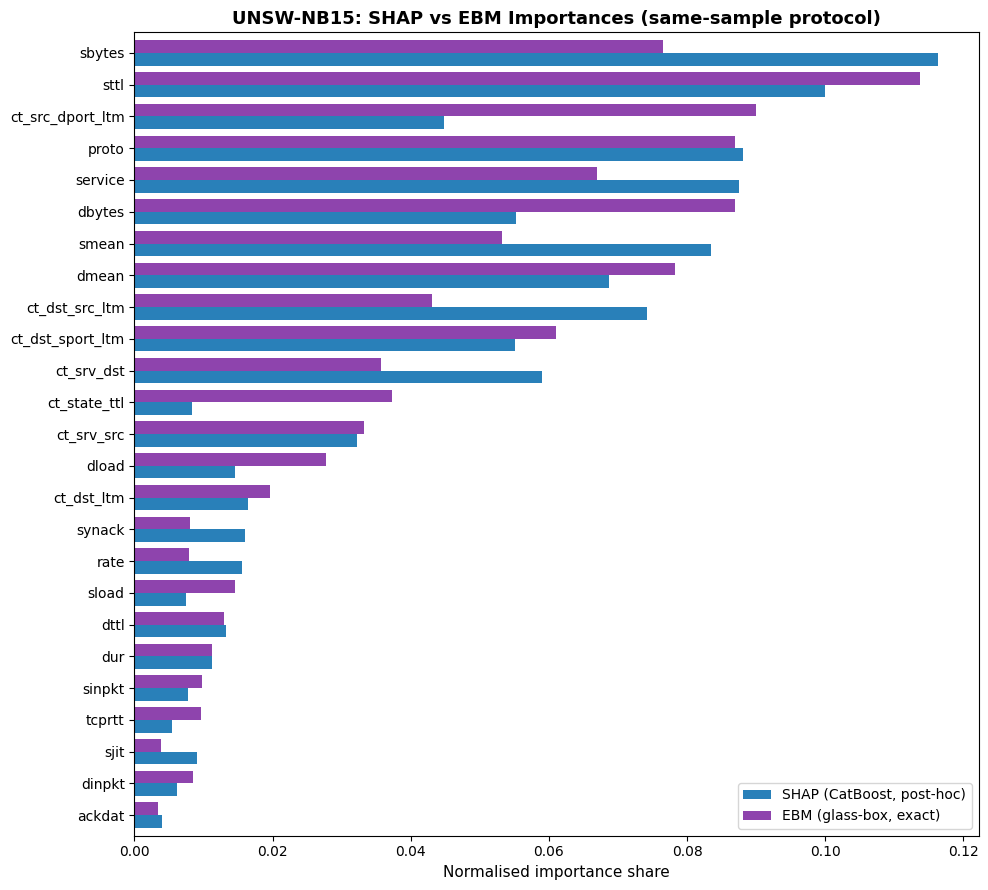

Saved -> Table_explanation_agreement_UNSW.csv, FigU6_Explanation_Agreement_UNSW.png


In [14]:
ebm_model = fitted_bases['EBM']
feats = list(X_subset.columns)

try:
    contrib = np.asarray(ebm_model.eval_terms(X_background))
    if contrib.ndim == 3:
        ebm_local_imp = np.abs(contrib).mean(axis=(0, 2))
    else:
        ebm_local_imp = np.abs(contrib).mean(axis=0)
    e = pd.Series(ebm_local_imp, index=ebm_model.term_names_).reindex(feats).fillna(0.0)
    protocol = 'eval_terms (same-sample, exact)'
except Exception as ex:
    print(f'eval_terms unavailable ({ex}); using global term_importances.')
    e = pd.Series(ebm_model.term_importances(),
                  index=ebm_model.term_names_).reindex(feats).fillna(0.0)
    protocol = 'term_importances (global fallback)'

s = shap_global_series.reindex(feats).fillna(0.0)
s_n = s / s.sum() if s.sum() > 0 else s
e_n = e / e.sum() if e.sum() > 0 else e
print(f'EBM attribution protocol: {protocol}')

def topk_feature_agreement(a, b, k):
    return len(set(a.nlargest(k).index) & set(b.nlargest(k).index)) / k
def topk_rank_agreement(a, b, k):
    ra = list(a.sort_values(ascending=False).index[:k])
    rb = list(b.sort_values(ascending=False).index[:k])
    return float(np.mean([ra[i] == rb[i] for i in range(k)]))

rows_ag = []
for k in (5, 10):
    rows_ag.append({'Metric': f'Top-{k} feature agreement',
                    'Value': round(topk_feature_agreement(s_n, e_n, k), 3)})
    rows_ag.append({'Metric': f'Top-{k} rank agreement',
                    'Value': round(topk_rank_agreement(s_n, e_n, k), 3)})
rho, rho_p = spearmanr(s_n.values, e_n.values)
tau, tau_p = kendalltau(s_n.values, e_n.values)
rows_ag += [{'Metric': 'Spearman rho (all features)', 'Value': round(rho, 3)},
            {'Metric': 'Spearman p-value', 'Value': f'{rho_p:.3e}'},
            {'Metric': 'Kendall tau (all features)', 'Value': round(tau, 3)},
            {'Metric': 'Kendall p-value', 'Value': f'{tau_p:.3e}'}]
agreement_table = pd.DataFrame(rows_ag)
print('===== EXPLANATION AGREEMENT — UNSW REPLICATION =====')
print(agreement_table.to_string(index=False))
agreement_table.to_csv('Table_explanation_agreement_UNSW.csv', index=False)
if rho_p < 0.05:
    print(f'\nREPLICATED: significant agreement (rho={rho:.3f}, p={rho_p:.2e}).')
    print('Manuscript claim: SHAP-EBM consistency generalises across datasets')
    print('and feature-extractor families.')
else:
    print(f'\nNOT replicated (rho={rho:.3f}, p={rho_p:.2e}). Report honestly and')
    print('use the divergence list below to discuss dataset-specific causes.')

div = (s_n - e_n).abs().sort_values(ascending=False)
print('\nLargest SHAP-vs-EBM divergences (top 5):')
for f, v in div.head(5).items():
    print(f'  {f:28s} |dShare| = {v:.4f}  (SHAP {s_n[f]:.4f} vs EBM {e_n[f]:.4f})')

comp = pd.DataFrame({'SHAP (CatBoost, post-hoc)': s_n,
                     'EBM (glass-box, exact)': e_n})
comp = comp.loc[comp.max(axis=1).sort_values(ascending=True).index]
ax = comp.plot(kind='barh', figsize=(10, 9), width=0.8,
               color=['#2980b9', '#8e44ad'])
ax.set_title('UNSW-NB15: SHAP vs EBM Importances (same-sample protocol)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Normalised importance share', fontsize=11)
plt.tight_layout()
plt.savefig('FigU6_Explanation_Agreement_UNSW.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved -> Table_explanation_agreement_UNSW.csv, FigU6_Explanation_Agreement_UNSW.png')


## 9. Charts

Generating charts...



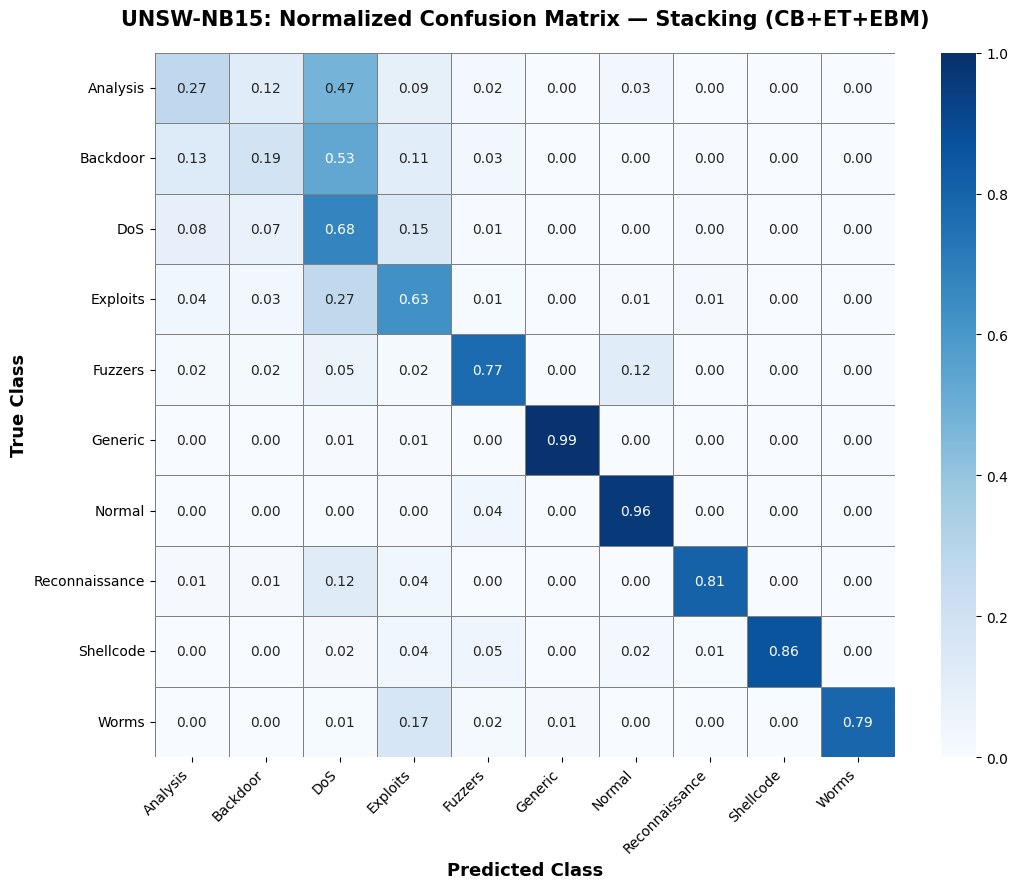

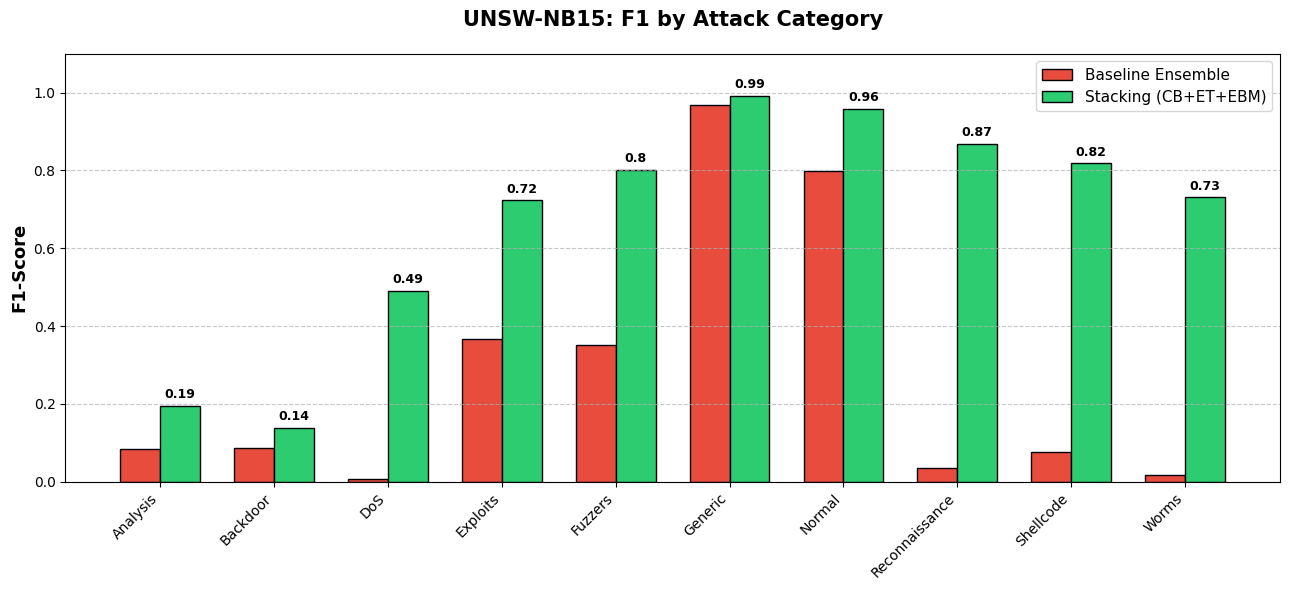

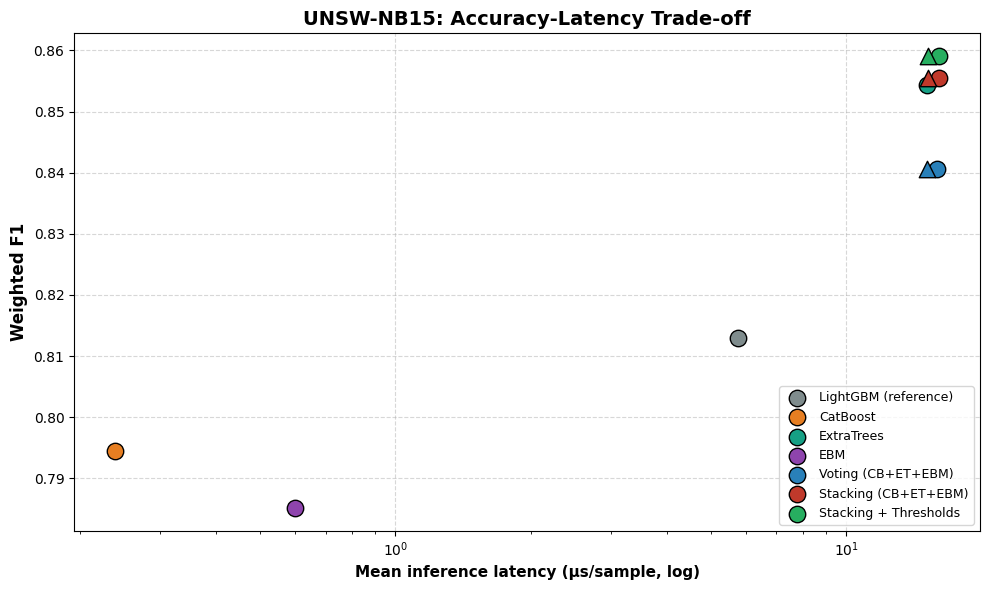

Charts saved.


In [15]:
print("Generating charts...\n")
y_pred_base  = np.array(mcnemar_data[BASE_KEY])
y_pred_stack = np.array(mcnemar_data[STACK_KEY])

unique_classes = np.unique(y_true_all)
class_names = [class_names_subset[i] for i in unique_classes]

cm = confusion_matrix(y_true_all, y_pred_stack)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(11, 9))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            vmin=0, vmax=1, linewidths=0.5, linecolor='gray')
plt.title('UNSW-NB15: Normalized Confusion Matrix — Stacking (CB+ET+EBM)',
          fontsize=15, fontweight='bold', pad=20)
plt.ylabel('True Class', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('FigU3_Confusion_Matrix_UNSW.png', dpi=300, bbox_inches='tight')
plt.show()

f1_base  = f1_score(y_true_all, y_pred_base,  average=None)
f1_stack = f1_score(y_true_all, y_pred_stack, average=None)
x = np.arange(len(class_names)); width = 0.35
plt.figure(figsize=(13, 6))
plt.bar(x - width/2, f1_base,  width, label='Baseline Ensemble',
        color='#e74c3c', edgecolor='black')
bars2 = plt.bar(x + width/2, f1_stack, width, label='Stacking (CB+ET+EBM)',
                color='#2ecc71', edgecolor='black')
plt.title('UNSW-NB15: F1 by Attack Category', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('F1-Score', fontsize=13, fontweight='bold')
plt.xticks(x, class_names, rotation=45, ha='right', fontsize=10)
plt.ylim(0, 1.1); plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             round(bar.get_height(), 2), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('FigU2_PerClass_F1_UNSW.png', dpi=300, bbox_inches='tight')
plt.show()

plot_keys = ['LightGBM (reference)', 'CatBoost', 'ExtraTrees', 'EBM',
             VOTE_KEY, STACK_KEY, THRESH_KEY]
lat = {k: np.mean(fold_metrics[k]['inf_us']) for k in plot_keys}
lat_par = {k: np.mean(fold_metrics[k]['inf_par_us']) for k in plot_keys}
f1w = {k: np.mean(fold_metrics[k]['f1']) for k in plot_keys}
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'LightGBM (reference)': '#7f8c8d', 'CatBoost': '#e67e22',
          'ExtraTrees': '#16a085', 'EBM': '#8e44ad',
          VOTE_KEY: '#2980b9', STACK_KEY: '#c0392b', THRESH_KEY: '#27ae60'}
for k in plot_keys:
    ax.scatter(lat[k], f1w[k], s=140, color=colors[k], edgecolor='black',
               zorder=3, label=k)
    if k in (VOTE_KEY, STACK_KEY, THRESH_KEY):
        ax.scatter(lat_par[k], f1w[k], s=140, color=colors[k], edgecolor='black',
                   marker='^', zorder=3)
ax.set_xscale('log')
ax.set_xlabel('Mean inference latency (\u00b5s/sample, log)', fontsize=11, fontweight='bold')
ax.set_ylabel('Weighted F1', fontsize=12, fontweight='bold')
ax.set_title('UNSW-NB15: Accuracy-Latency Trade-off', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('FigU7_Latency_F1_Pareto_UNSW.png', dpi=300, bbox_inches='tight')
plt.show()
print('Charts saved.')


## 10. Final Reports + Artefacts

In [16]:
present_labels = np.unique(y_true_all)
present_target_names = [class_names_subset[i] for i in present_labels]

print("=== UNSW-NB15 per-class report: Stacking, pooled over 5 folds ===\n")
print(classification_report(y_true_all, np.array(mcnemar_data[STACK_KEY]),
                            labels=present_labels,
                            target_names=present_target_names, digits=2))
print("\n=== UNSW-NB15 per-class report: Stacking + Thresholds ===\n")
print(classification_report(y_true_all, np.array(mcnemar_data[THRESH_KEY]),
                            labels=present_labels,
                            target_names=present_target_names, digits=2))

joblib.dump(fitted_bases, 'unsw_base_models.pkl')
joblib.dump(fitted_meta,  'unsw_stacking_meta.pkl')
joblib.dump({'fold_thresholds': fold_thresholds,
             'mean_thresholds': mean_thresholds,
             'class_names': class_names_subset}, 'unsw_class_thresholds.pkl')
joblib.dump(scaler, 'unsw_scaler.pkl')
joblib.dump(label_encoder, 'unsw_label_encoder.pkl')
joblib.dump(subset_le, 'unsw_subset_label_encoder.pkl')
joblib.dump(selected_features, 'unsw_selected_features.pkl')
import json as _json
with open('unsw_class_names.json', 'w') as _f:
    _json.dump(class_names_subset, _f, indent=2)
print('\nArtifacts saved (unsw_* prefix).')


=== UNSW-NB15 per-class report: Stacking, pooled over 5 folds ===

                precision    recall  f1-score   support

      Analysis       0.15      0.27      0.19      4677
      Backdoor       0.11      0.19      0.14      4075
           DoS       0.38      0.68      0.49     28617
      Exploits       0.85      0.63      0.72     77918
       Fuzzers       0.83      0.77      0.80     42430
       Generic       1.00      0.99      0.99     98871
        Normal       0.96      0.96      0.96    149000
Reconnaissance       0.94      0.81      0.87     24478
     Shellcode       0.78      0.86      0.82      2644
         Worms       0.68      0.79      0.73       304

      accuracy                           0.84    433014
     macro avg       0.67      0.69      0.67    433014
  weighted avg       0.88      0.84      0.86    433014


=== UNSW-NB15 per-class report: Stacking + Thresholds ===

                precision    recall  f1-score   support

      Analysis       0.65    